# CLIP Similarity Demo

## Mục tiêu

Notebook này minh họa việc sử dụng mô hình CLIP để:

- Trích xuất đặc trưng ảnh.
- Trích xuất đặc trưng văn bản.
- Tính độ tương đồng giữa ảnh và văn bản.
- Hỗ trợ phát hiện nội dung không khớp giữa ảnh và văn bản.

## Mô hình sử dụng

- openai/clip-vit-base-patch32

## Quy trình

Image + Text
↓
CLIP Encoder
↓
Embedding
↓
Cosine Similarity
↓
Similarity Score

In [ ]:
import torch

from src.models.clip_model import (
    compute_clip_similarity,
    analyze_image_text,
    get_text_embedding
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from PIL import Image

In [1]:
# Import thư viện

import sys
import os

# Lấy thư mục cha của notebooks
project_root = os.path.abspath("..")

# Thêm vào Python Path
sys.path.append(project_root)

print(project_root)
from src.models.clip_model import (
    compute_clip_similarity,
    analyze_image_text,
    get_text_embedding,
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from PIL import Image

print("Libraries loaded successfully!")

c:\Users\ASUS\Downloads\nhom1-xulianh-thigiacmaytinh-main
Libraries loaded successfully!


## Bước 1: Hiển thị ảnh đầu vào

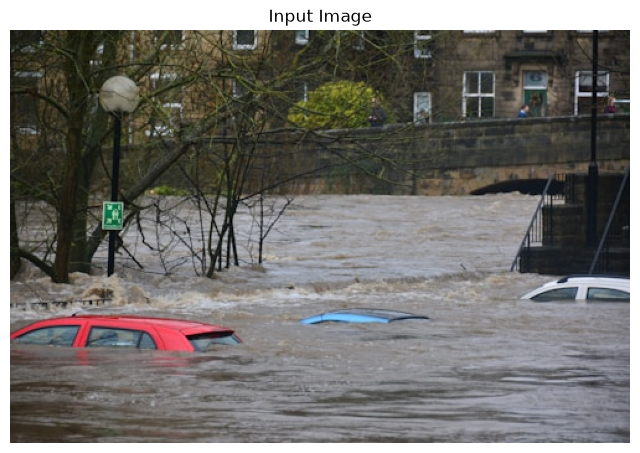

In [2]:
image_path = "../data/demo_cases/images/test.jpg"

img = Image.open(image_path)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

## Bước 2: Khai báo nhiều câu mô tả để kiểm tra

In [3]:
captions = [

    "A flooded street in Hanoi.",

    "People walking on a flooded road.",

    "Cars moving on a street.",

    "A football match in a stadium.",

    "A cat sleeping on a sofa."
]

captions

['A flooded street in Hanoi.',
 'People walking on a flooded road.',
 'Cars moving on a street.',
 'A football match in a stadium.',
 'A cat sleeping on a sofa.']

## Bước 3: Tính similarity giữa ảnh và từng caption

In [4]:
results = []

for caption in captions:

    result = compute_clip_similarity(
        image_path,
        caption
    )

    results.append({
        "Caption": caption,
        "Similarity Score": result["similarity_score"]
    })

df = pd.DataFrame(results)

df = df.sort_values(
    by="Similarity Score",
    ascending=False
)

df

[CLIP] Đang tải mô hình openai/clip-vit-base-patch32... (Lần đầu có thể mất 10-30 giây)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[CLIP] ✅ Tải mô hình thành công! Chạy trên: CPU


,Caption,Similarity Score
1,People walking on a flooded road.,0.273159
2,Cars moving on a street.,0.236107
0,A flooded street in Hanoi.,0.225072
3,A football match in a stadium.,0.181171
4,A cat sleeping on a sofa.,0.103726


## Bước 4: Trực quan hóa kết quả bằng biểu đồ

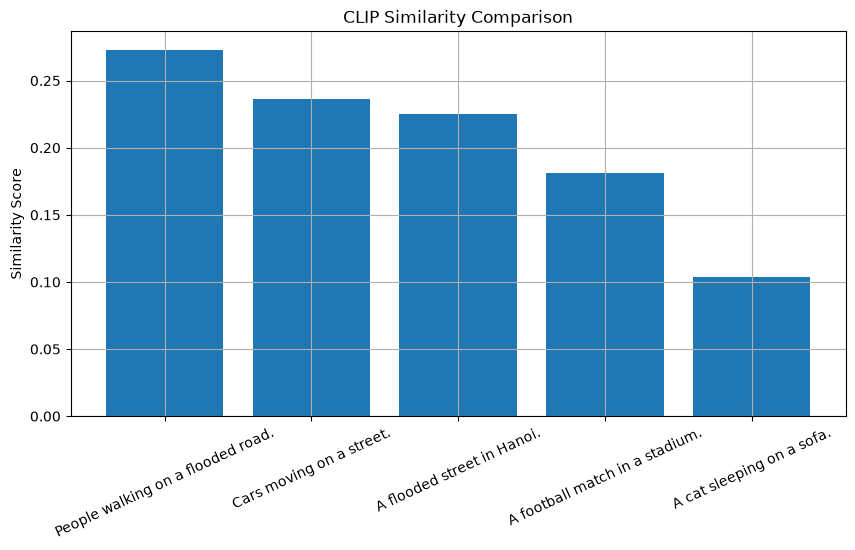

In [5]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Caption"],
    df["Similarity Score"]
)

plt.xticks(rotation=25)

plt.ylabel("Similarity Score")

plt.title("CLIP Similarity Comparison")

plt.grid()

plt.show()

## Bước 5: Phân tích mức độ khớp giữa ảnh và văn bản

In [6]:
test_cases = [

    "Flood in Ho Chi Minh City",

    "People are walking in flood water",

    "A cute puppy playing in the garden",

    "Political meeting in parliament"
]

for text in test_cases:

    analysis = analyze_image_text(
        image_path,
        text
    )

    print("=" * 70)

    print("Text:", text)

    print("Similarity:",
          analysis["similarity_score"])

    print("Match Level:",
          analysis["match_level"])

    print("Suspicious:",
          analysis["is_suspicious"])

    print("Interpretation:",
          analysis["interpretation"])

Text: Flood in Ho Chi Minh City
Similarity: 0.22437019646167755
Match Level: Hoàn toàn không khớp - Rất nghi ngờ tin giả
Suspicious: True
Interpretation: Ảnh và nội dung không khớp → Có dấu hiệu tin giả
Text: People are walking in flood water
Similarity: 0.2848476469516754
Match Level: Hoàn toàn không khớp - Rất nghi ngờ tin giả
Suspicious: True
Interpretation: Ảnh và nội dung không khớp → Có dấu hiệu tin giả
Text: A cute puppy playing in the garden
Similarity: 0.13857688009738922
Match Level: Hoàn toàn không khớp - Rất nghi ngờ tin giả
Suspicious: True
Interpretation: Ảnh và nội dung không khớp → Có dấu hiệu tin giả
Text: Political meeting in parliament
Similarity: 0.15587358176708221
Match Level: Hoàn toàn không khớp - Rất nghi ngờ tin giả
Suspicious: True
Interpretation: Ảnh và nội dung không khớp → Có dấu hiệu tin giả


## Bước 6: Trực quan hóa không gian embedding (PCA)

Giảm chiều embedding từ 512 chiều xuống 2 chiều để quan sát sự khác biệt giữa các mô tả văn bản.

In [7]:
from sklearn.decomposition import PCA

In [8]:
embeddings = []

for text in captions:

    emb = get_text_embedding(text)

    embeddings.append(
        emb.cpu().numpy()
    )

embeddings = np.array(embeddings)

print(embeddings.shape)

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [9]:
pca = PCA(n_components=2)

points = pca.fit_transform(embeddings)

plt.figure(figsize=(8,8))

for i, text in enumerate(captions):

    plt.scatter(points[i,0], points[i,1])

    plt.text(
        points[i,0],
        points[i,1],
        text,
        fontsize=9
    )

plt.title("PCA Visualization of Text Embeddings")

plt.grid()

plt.show()

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

# Kết luận

- CLIP có khả năng đo độ tương đồng giữa ảnh và văn bản.
- Các mô tả đúng ngữ cảnh thường có similarity cao.
- Các mô tả không liên quan thường có similarity thấp.
- Kết quả này có thể được sử dụng như một đặc trưng quan trọng trong hệ thống phát hiện tin giả đa phương thức.

In [11]:
from src.models.clip_model import load_clip_model


model, processor, device = load_clip_model()

inputs = processor(
    text=["hello world"],
    return_tensors="pt",
    padding=True
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

with torch.no_grad():
    output = model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

print(type(output))
print(output)

NameError: name 'torch' is not defined